(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
Loan_ID               0
Gender               13
Married               3
Dependents           15
E

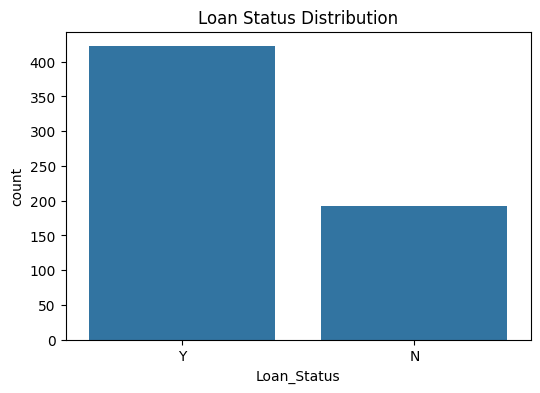

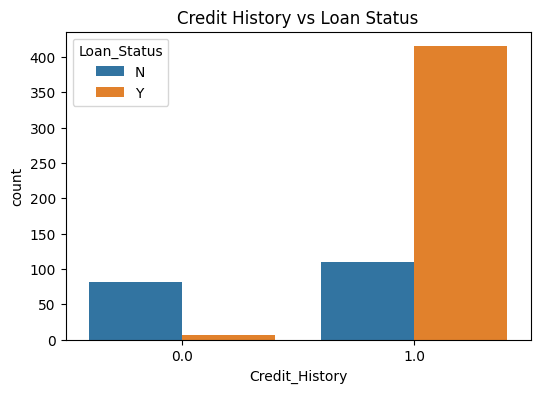

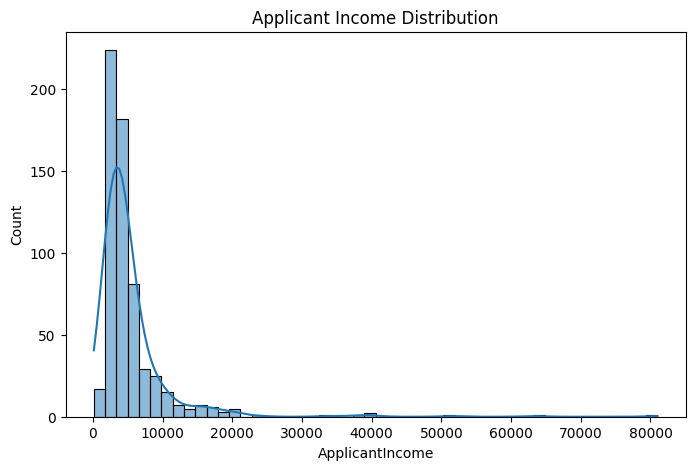

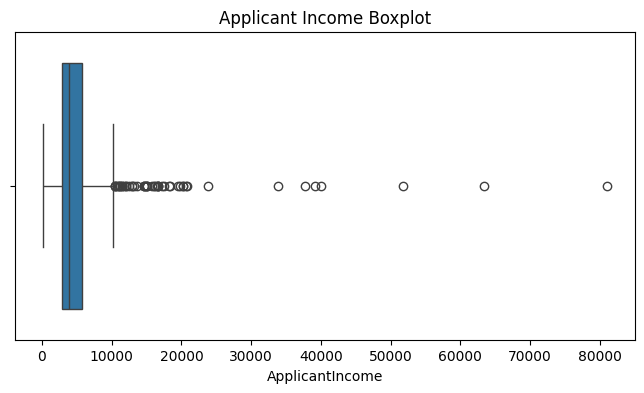

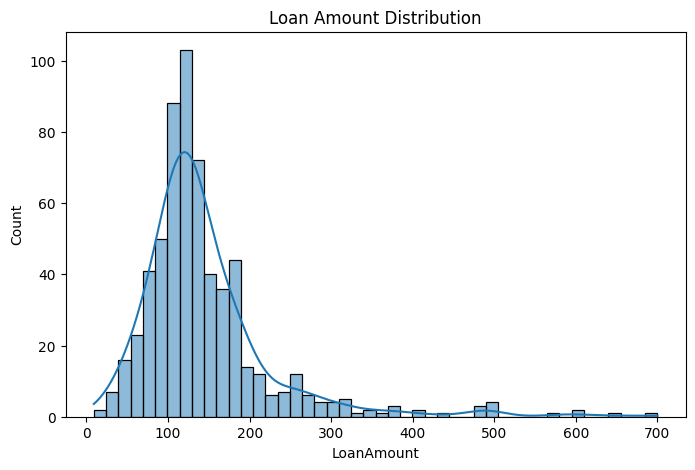

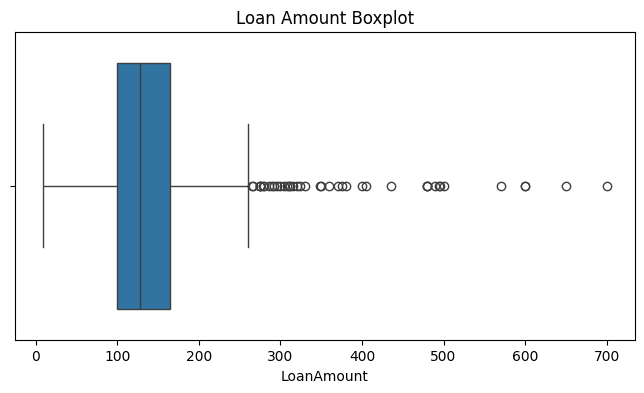

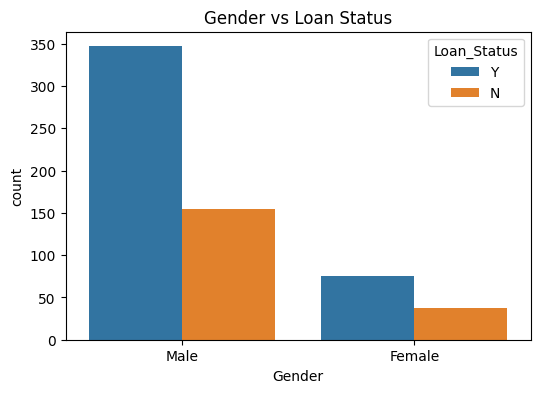

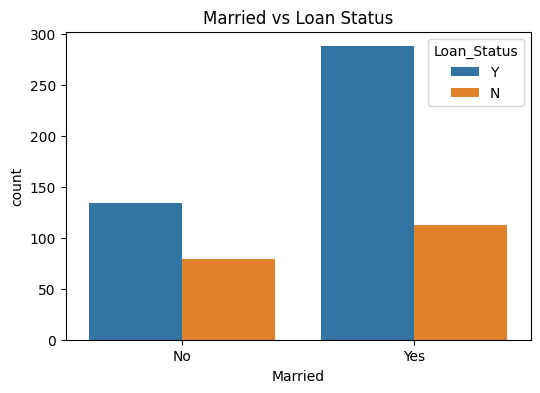

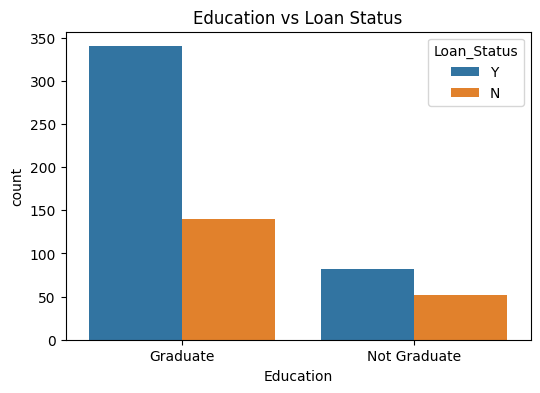

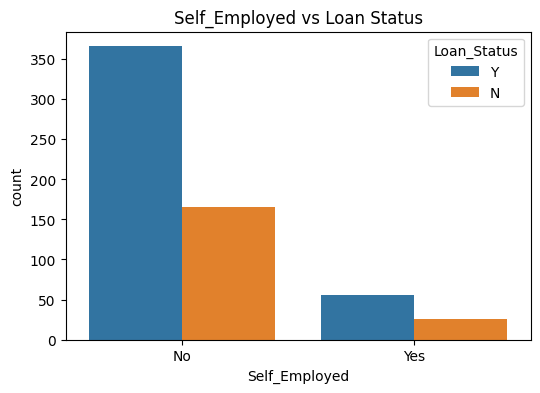

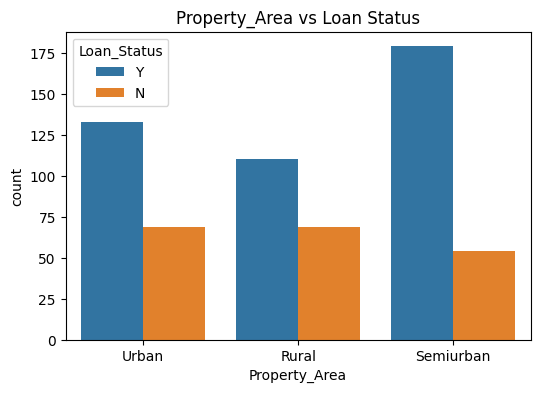

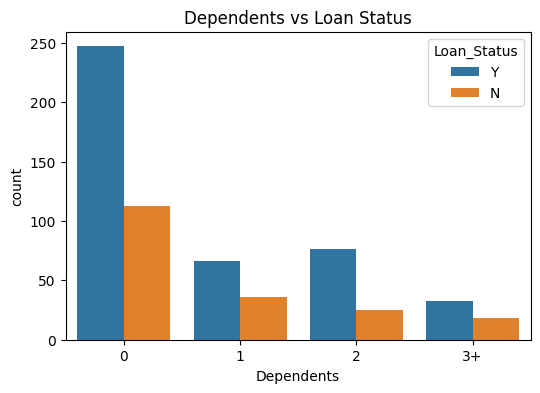

C:\Users\sonia\AppData\Local\Temp\ipykernel_18984\3261495802.py:85: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(category_mapping)


   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0             5849   
1       1        1           1          1              0             4583   
2       1        1           0          1              1             3000   
3       1        1           0          0              0             2583   
4       1        0           0          1              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  Property_Area_Semiurban  Property_Area_Urban  
0            1                    False              

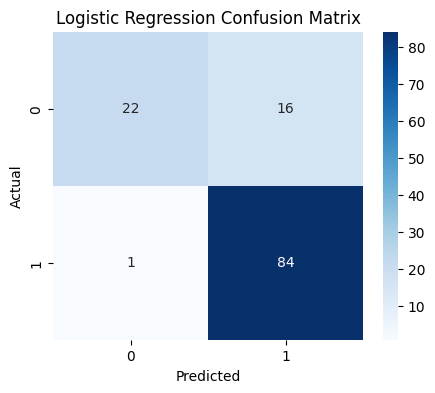

Decision Tree Accuracy: 0.7398373983739838
              precision    recall  f1-score   support

           0       0.57      0.63      0.60        38
           1       0.83      0.79      0.81        85

    accuracy                           0.74       123
   macro avg       0.70      0.71      0.70       123
weighted avg       0.75      0.74      0.74       123



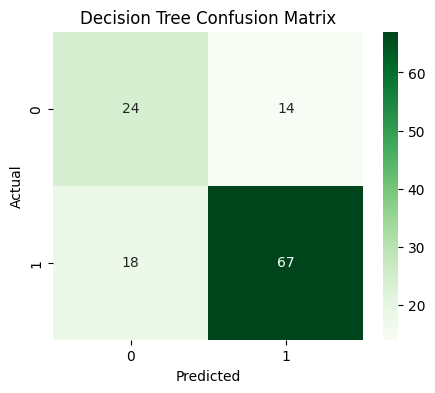

Random Forest Accuracy: 0.8211382113821138
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123



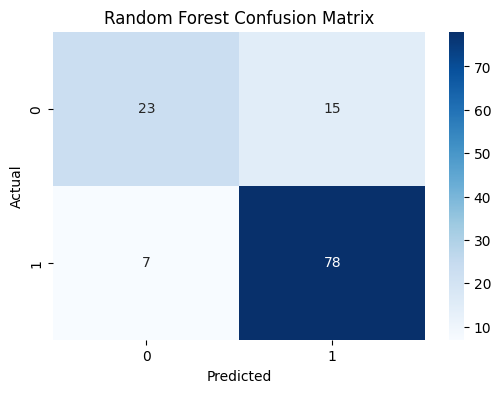

                    Feature  Importance
4             Self_Employed    0.018793
0                    Gender    0.019172
11      Property_Area_Urban    0.023864
3                 Education    0.024818
1                   Married    0.025856
10  Property_Area_Semiurban    0.028107
2                Dependents    0.051057
8          Loan_Amount_Term    0.051907
6         CoapplicantIncome    0.111876
7                LoanAmount    0.202461
5           ApplicantIncome    0.207562
9            Credit_History    0.234527


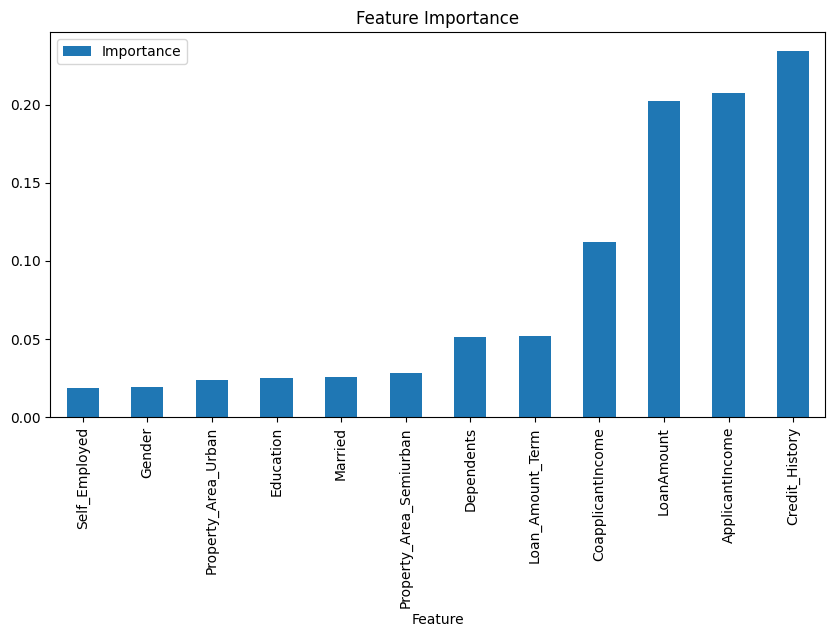

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross Validation Score: 0.8004122861265719
Tuned Random Forest Accuracy: 0.8536585365853658
              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



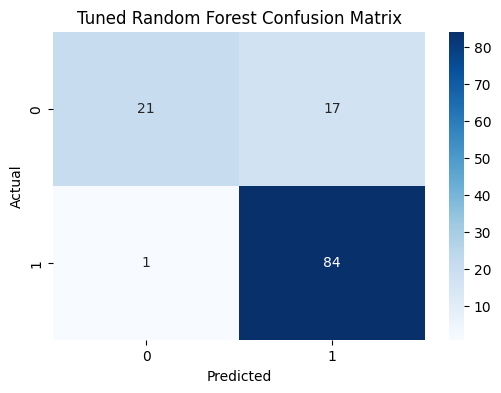

Best model and scaler saved successfully


c:\Users\sonia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Sample prediction: [1]
Loan Approved


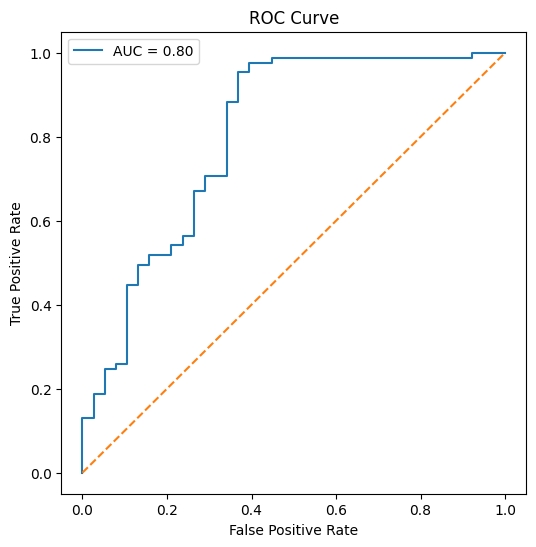

AUC Score: 0.8043343653250774


2026-07-11 16:52:36.897 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 16:52:47.952 
  command:

    streamlit run C:\Users\sonia\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-11 16:52:48.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 16:52:48.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import joblib

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    r"C:\Users\sonia\Downloads\project for data scintist inreal project\loan_default_prediction\dataset .csv"
)

# Basic dataset checks
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df['Loan_Status'].value_counts())

# Fill missing values
for col in ['Gender', 'Credit_History', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

print("Missing values after imputation:\n", df.isnull().sum())

# Exploratory Data Analysis
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status')
plt.title("Loan Status Distribution")
plt.savefig("loan_status_distribution.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')
plt.title("Credit History vs Loan Status")
plt.savefig("credit_history_vs_loan_status.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.savefig("applicant_income_distribution.png")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['ApplicantIncome'])
plt.title("Applicant Income Boxplot")
plt.savefig("applicant_income_boxplot.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.savefig("loan_amount_distribution.png")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Boxplot")
plt.savefig("loan_amount_boxplot.png")
plt.show()

for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='Loan_Status')
    plt.title(f"{col} vs Loan Status")
    plt.savefig(f"{col.lower()}_vs_loan_status.png")
    plt.show()

# Preprocessing for modeling
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

category_mapping = {
    'Gender': {'Male': 1, 'Female': 0},
    'Married': {'Yes': 1, 'No': 0},
    'Education': {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status': {'Y': 1, 'N': 0}
}

df = df.replace(category_mapping)
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print(df.head())
print(df.dtypes)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("logistic_confusion_matrix.png")
plt.show()

# Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("decision_tree_confusion_matrix.png")
plt.show()

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("random_forest_confusion_matrix.png")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)
print(importance)
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10, 5)
)
plt.title('Feature Importance')
plt.savefig('feature_importance.png')
plt.show()

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

best_rf = grid.best_estimator_
rf_tuned_pred = best_rf.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, rf_tuned_pred))
print(classification_report(y_test, rf_tuned_pred))

cm = confusion_matrix(y_test, rf_tuned_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("random_forest_tuned_confusion_matrix.png")
plt.show()

joblib.dump(best_rf, "loan_prediction_best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best model and scaler saved successfully")

sample = [[
    1,      # Gender
    1,      # Married
    1,      # Dependents
    1,      # Education
    0,      # Self_Employed
    5000,   # ApplicantIncome
    1500,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1,      # Credit_History
    1,      # Property_Area_Semiurban
    0       # Property_Area_Urban
]]

scaled_sample = scaler.transform(sample)
loaded_model = joblib.load("loan_prediction_best_model.pkl")
prediction = loaded_model.predict(scaled_sample)
print("Sample prediction:", prediction)
print("Loan Approved" if prediction[0] == 1 else "Loan Rejected")

if hasattr(loaded_model, 'predict_proba'):
    y_prob = loaded_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig("roc_curve.png")
    plt.show()
    print("AUC Score:", roc_auc)
else:
    print("Loaded model does not support predict_proba")

st.title("Loan Approval Prediction")
